In [1]:
import pandas as pd
import numpy as np
import math
import time
import warnings

# Suppress annoying SDV/Pandas warnings to keep the notebook output clean
warnings.filterwarnings('ignore')

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
def get_stratified_sample(df, target_col, sample_size):
    """
    Pandas-native Stratified Sampling function.
    Maintains exact proportions of the target column.
    """
    proportions = df[target_col].value_counts(normalize=True)
    pieces = []
    
    for val, prop in proportions.items():
        n_items = int(round(prop * sample_size))
        subset = df[df[target_col] == val]
        pieces.append(subset.sample(n=n_items, replace=False))
        
    stratified_df = pd.concat(pieces).sample(frac=1).reset_index(drop=True)
    
    if len(stratified_df) > sample_size:
        stratified_df = stratified_df.head(sample_size)
        
    return stratified_df

def get_boundary_sample(df, sample_size):
    """
    Boundary/Edge-Case Sampling function.
    Hunts for anomalies and balances them equally with normal stereotypes.
    """
    healthy_anomalies = df[(df['Diabetes_binary'] == 0.0) & ((df['BMI'] > 35) | (df['HighBP'] == 1.0) | (df['Smoker'] == 1.0))]
    diabetic_anomalies = df[(df['Diabetes_binary'] == 1.0) & (df['BMI'] < 25) & (df['PhysActivity'] == 1.0)]
    normal_healthy = df[(df['Diabetes_binary'] == 0.0) & (df['BMI'] <= 25) & (df['HighBP'] == 0.0)]
    normal_diabetic = df[(df['Diabetes_binary'] == 1.0) & (df['BMI'] > 30) & (df['HighBP'] == 1.0)]
    
    quota = sample_size // 4
    remainder = sample_size % 4 
    
    pieces = [
        healthy_anomalies.sample(n=quota, replace=True),
        diabetic_anomalies.sample(n=quota, replace=True),
        normal_healthy.sample(n=quota, replace=True),
        normal_diabetic.sample(n=quota + remainder, replace=True)
    ]
    
    boundary_df = pd.concat(pieces).sample(frac=1).reset_index(drop=True)
    return boundary_df

print("Both sampling engines ready!")

Both sampling engines ready!


In [3]:
print("======================================================")
print(" 🚀 DUAL BOOTSTRAPPED GAUSSIAN COPULA GENERATOR")
print("======================================================\n")

# --- 1. SETTINGS & INITIALIZATION ---
input_file = 'diabetes_binary_health_indicators_BRFSS2015.csv'

# Stratified Output Files
strat_sampled_csv = 'sampled_data_accumulated.csv'
strat_synthetic_csv = 'synthetic_data_accumulated.csv'

# Boundary Output Files
bound_sampled_csv = 'boundary_sampled_accumulated.csv'
bound_synthetic_csv = 'boundary_synthetic_accumulated.csv'

TOTAL_ITERATIONS = 100

print("1. Loading raw CDC data...")
raw_data = pd.read_csv(input_file)
n_total_rows = len(raw_data)

# Calculate sizes based on the math pattern
sample_size = int(math.sqrt(n_total_rows))
synthetic_size_per_loop = sample_size * 10

print(f"   -> Raw Data Rows (N): {n_total_rows:,}")
print(f"   -> Sample Size per loop (√N): {sample_size:,}")
print(f"   -> Synthetic Size per loop (√N * 10): {synthetic_size_per_loop:,}")
print(f"   -> Total Loops Planned: {TOTAL_ITERATIONS:,}\n")

# --- 2. METADATA DETECTION ---
print("2. Detecting Data Metadata (Only done once)...")
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(raw_data)
print("   -> Metadata locked in.\n")

# --- 3. THE MASTER LOOP ---
print(f"3. Starting {TOTAL_ITERATIONS} DUAL AI Training & Generation Loops...\n")

start_time_total = time.time()

for i in range(TOTAL_ITERATIONS):
    loop_start = time.time()
    
    # ==========================================
    # WORKFLOW A: STRATIFIED SAMPLING
    # ==========================================
    current_strat_sample = get_stratified_sample(raw_data, 'Diabetes_binary', sample_size)
    
    if i == 0:
        current_strat_sample.to_csv(strat_sampled_csv, index=False, mode='w')
    else:
        current_strat_sample.to_csv(strat_sampled_csv, index=False, mode='a', header=False)
        
    strat_synthesizer = GaussianCopulaSynthesizer(metadata)
    strat_synthesizer.fit(current_strat_sample)
    current_strat_synthetic = strat_synthesizer.sample(num_rows=synthetic_size_per_loop)
    
    if i == 0:
        current_strat_synthetic.to_csv(strat_synthetic_csv, index=False, mode='w')
    else:
        current_strat_synthetic.to_csv(strat_synthetic_csv, index=False, mode='a', header=False)

    # ==========================================
    # WORKFLOW B: BOUNDARY SAMPLING
    # ==========================================
    current_bound_sample = get_boundary_sample(raw_data, sample_size)
    
    if i == 0:
        current_bound_sample.to_csv(bound_sampled_csv, index=False, mode='w')
    else:
        current_bound_sample.to_csv(bound_sampled_csv, index=False, mode='a', header=False)
        
    bound_synthesizer = GaussianCopulaSynthesizer(metadata)
    bound_synthesizer.fit(current_bound_sample)
    current_bound_synthetic = bound_synthesizer.sample(num_rows=synthetic_size_per_loop)
    
    if i == 0:
        current_bound_synthetic.to_csv(bound_synthetic_csv, index=False, mode='w')
    else:
        current_bound_synthetic.to_csv(bound_synthetic_csv, index=False, mode='a', header=False)

    # ==========================================
    # CONSOLE PROGRESS & TIME ESTIMATION
    # ==========================================
    loop_duration = time.time() - loop_start
    
    if i == 0:
        estimated_total_seconds = loop_duration * TOTAL_ITERATIONS
        est_hours = estimated_total_seconds // 3600
        est_minutes = (estimated_total_seconds % 3600) // 60
        print(f"   [⏳ ESTIMATE] Based on Loop 1, this dual-process will take ~{int(est_hours)}h {int(est_minutes)}m to finish.")
        print("   ------------------------------------------------------")
        
    if (i + 1) % 10 == 0 or i == 0:
        print(f"   -> Completed Loop {i + 1}/{TOTAL_ITERATIONS} | Accumulated Rows (Per Method): {(i + 1) * synthetic_size_per_loop:,}")

# --- 4. COMPLETION ---
total_time_mins = (time.time() - start_time_total) / 60
print("\n======================================================")
print(f" 🎉 DUAL EXPERIMENT COMPLETE!")
print(f" Time Taken: {total_time_mins:.2f} minutes")
print(f" Files Saved:")
print(f"   - Stratified: '{strat_sampled_csv}' & '{strat_synthetic_csv}'")
print(f"   - Boundary:   '{bound_sampled_csv}' & '{bound_synthetic_csv}'")
print("======================================================")

 🚀 DUAL BOOTSTRAPPED GAUSSIAN COPULA GENERATOR

1. Loading raw CDC data...
   -> Raw Data Rows (N): 253,680
   -> Sample Size per loop (√N): 503
   -> Synthetic Size per loop (√N * 10): 5,030
   -> Total Loops Planned: 100

2. Detecting Data Metadata (Only done once)...
   -> Metadata locked in.

3. Starting 100 DUAL AI Training & Generation Loops...

   [⏳ ESTIMATE] Based on Loop 1, this dual-process will take ~0h 9m to finish.
   ------------------------------------------------------
   -> Completed Loop 1/100 | Accumulated Rows (Per Method): 5,030
   -> Completed Loop 10/100 | Accumulated Rows (Per Method): 50,300
   -> Completed Loop 20/100 | Accumulated Rows (Per Method): 100,600
   -> Completed Loop 30/100 | Accumulated Rows (Per Method): 150,900
   -> Completed Loop 40/100 | Accumulated Rows (Per Method): 201,200
   -> Completed Loop 50/100 | Accumulated Rows (Per Method): 251,500
   -> Completed Loop 60/100 | Accumulated Rows (Per Method): 301,800
   -> Completed Loop 70/100 | 

In [5]:
!pip install matplotlib seaborn scipy scikit-learn

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading datasets...

 RUNNING EVALUATION 1: STRATIFIED SAMPLING
 -> Wasserstein Distance: 0.4928
 -> Discriminator AUC:    0.7229


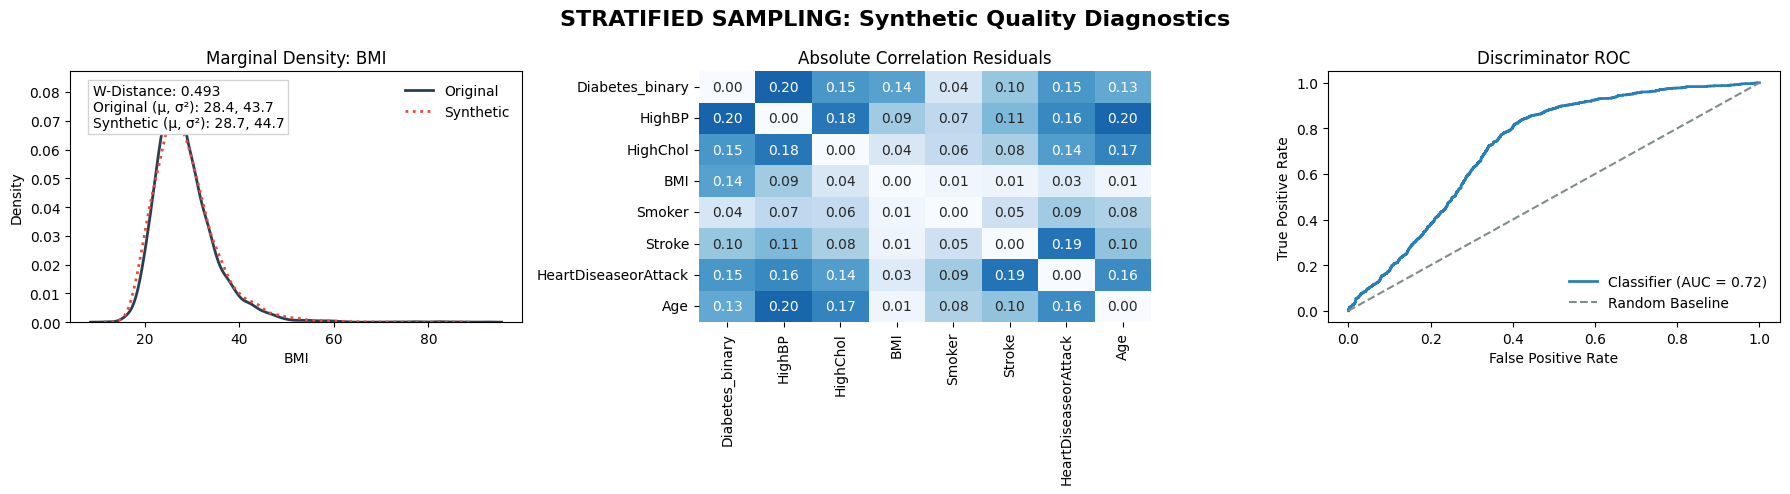


 RUNNING EVALUATION 2: BOUNDARY SAMPLING
 -> Wasserstein Distance: 1.4114
 -> Discriminator AUC:    0.7729


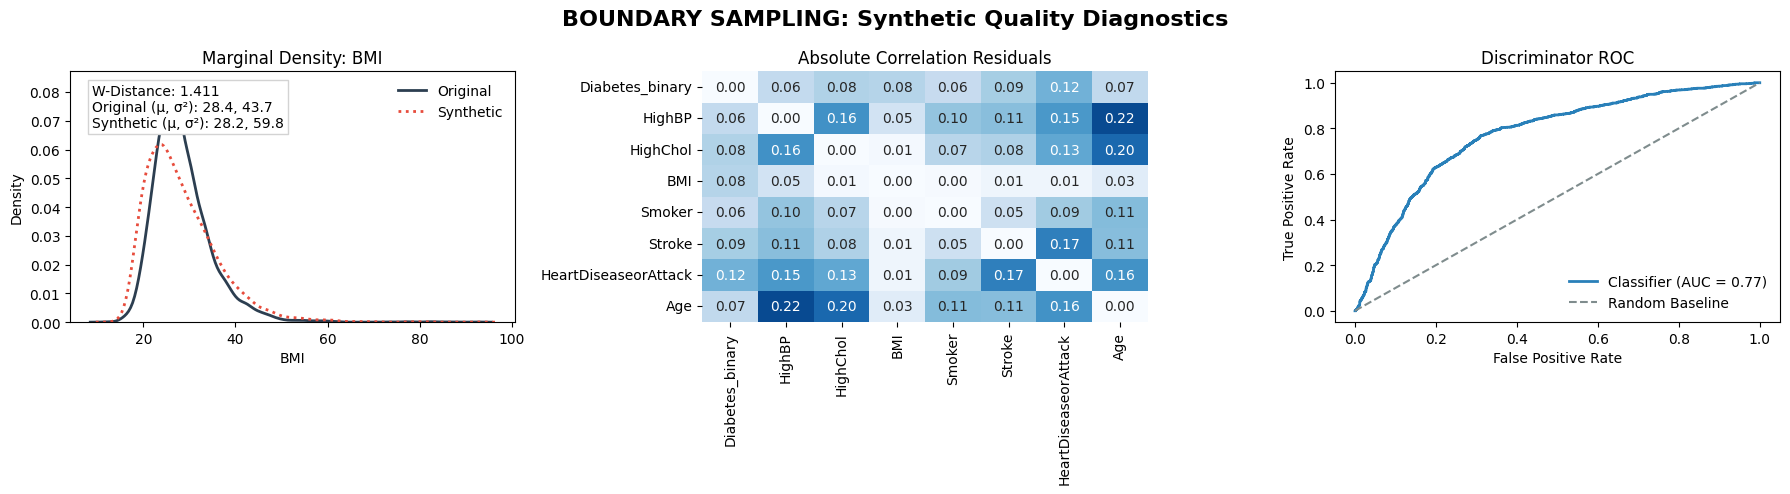

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

def compute_advanced_metrics(real_df, synth_df, target_feature='BMI'):
    """Calculates statistical distances and discriminator AUC for synthetic data."""
    metrics = {}
    
    # 1. Central Tendency & Variance
    metrics['real_mean'] = real_df[target_feature].mean()
    metrics['real_var'] = real_df[target_feature].var()
    metrics['synth_mean'] = synth_df[target_feature].mean()
    metrics['synth_var'] = synth_df[target_feature].var()
    
    # 2. Earth Mover's Distance (Wasserstein)
    n_samples = min(5000, len(real_df), len(synth_df))
    real_sub = real_df[target_feature].sample(n=n_samples, random_state=42)
    synth_sub = synth_df[target_feature].sample(n=n_samples, random_state=42)
    
    metrics['wasserstein'] = wasserstein_distance(real_sub, synth_sub)
    
    # 3. Correlation Matrix Residuals
    eval_cols = ['Diabetes_binary', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'Age']
    valid_cols = [c for c in eval_cols if c in real_df.columns]
    
    real_c = real_df[valid_cols].corr()
    synth_c = synth_df[valid_cols].corr()
    metrics['corr_residuals'] = (real_c - synth_c).abs()
    
    # 4. Discriminator Model (Propensity Score)
    real_labeled = real_df.sample(n=n_samples, random_state=42).copy()
    real_labeled['target_label'] = 1
    
    synth_labeled = synth_df.sample(n=n_samples, random_state=42).copy()
    synth_labeled['target_label'] = 0
    
    combined_set = pd.concat([real_labeled, synth_labeled])
    features = combined_set.drop('target_label', axis=1)
    labels = combined_set['target_label']
    
    x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)
    
    clf = LogisticRegression(max_iter=1000, solver='lbfgs')
    clf.fit(x_train, y_train)
    
    probs = clf.predict_proba(x_test)[:, 1]
    metrics['discriminator_auc'] = roc_auc_score(y_test, probs)
    metrics['roc_data'] = roc_curve(y_test, probs)
    
    return metrics, real_sub, synth_sub


def generate_evaluation_dashboard(metrics_dict, real_dist, synth_dist, feature_name, title_prefix, save_path=None):
    """Renders a 1x3 diagnostic plot for the synthetic data generation."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.subplots_adjust(top=0.85)
    fig.suptitle(f"{title_prefix}: Synthetic Quality Diagnostics", fontsize=16, fontweight='600')

    # Panel A: Density Overlay
    sns.kdeplot(real_dist, ax=axes[0], color='#2c3e50', label='Original', lw=2)
    sns.kdeplot(synth_dist, ax=axes[0], color='#e74c3c', label='Synthetic', lw=2, ls=':')
    axes[0].set_title(f"Marginal Density: {feature_name}")
    axes[0].legend(frameon=False)
    
    stat_box = (
        f"W-Distance: {metrics_dict['wasserstein']:.3f}\n"
        f"Original (μ, σ²): {metrics_dict['real_mean']:.1f}, {metrics_dict['real_var']:.1f}\n"
        f"Synthetic (μ, σ²): {metrics_dict['synth_mean']:.1f}, {metrics_dict['synth_var']:.1f}"
    )
    axes[0].text(0.05, 0.95, stat_box, transform=axes[0].transAxes, va='top', 
                 bbox=dict(boxstyle='square', fc='white', ec='lightgray'))

    # Panel B: Residual Heatmap
    sns.heatmap(metrics_dict['corr_residuals'], ax=axes[1], annot=True, fmt=".2f", 
                cmap='Blues', cbar=False, vmin=0, vmax=0.25)
    axes[1].set_title("Absolute Correlation Residuals")

    # Panel C: ROC Curve
    fpr, tpr, _ = metrics_dict['roc_data']
    auc_val = metrics_dict['discriminator_auc']
    
    axes[2].plot(fpr, tpr, color='#2980b9', lw=2, label=f'Classifier (AUC = {auc_val:.2f})')
    axes[2].plot([0, 1], [0, 1], color='#7f8c8d', ls='--', label='Random Baseline')
    axes[2].set(title="Discriminator ROC", xlabel="False Positive Rate", ylabel="True Positive Rate")
    axes[2].legend(loc='lower right', frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show() # Swapped from plt.close() so it renders in Jupyter

# =====================================================================
# EXECUTION BLOCK: COMPARING RAW VS. STRATIFIED VS. BOUNDARY
# =====================================================================
if __name__ == "__main__":
    print("Loading datasets...")
    # NOTE: Ensure these filenames exactly match the ones saved in your folder
    raw_df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    
    # -> THIS IS THE ONLY LINE THAT WAS CHANGED <-
    strat_synth_df = pd.read_csv('stratified_synthetic_accumulated.csv')
    
    bound_synth_df = pd.read_csv('boundary_synthetic_accumulated.csv')
    
    feature_to_test = 'BMI'

    # ---------------------------------------------------------
    # TEST 1: STRATIFIED SAMPLING
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print(" RUNNING EVALUATION 1: STRATIFIED SAMPLING")
    print("="*50)
    
    strat_metrics, raw_sub_strat, synth_sub_strat = compute_advanced_metrics(raw_df, strat_synth_df, target_feature=feature_to_test)
    
    print(f" -> Wasserstein Distance: {strat_metrics['wasserstein']:.4f}")
    print(f" -> Discriminator AUC:    {strat_metrics['discriminator_auc']:.4f}")
    
    generate_evaluation_dashboard(
        strat_metrics, raw_sub_strat, synth_sub_strat, 
        feature_name=feature_to_test, 
        title_prefix="STRATIFIED SAMPLING",
        save_path="Evaluation_Stratified.png"
    )

    # ---------------------------------------------------------
    # TEST 2: BOUNDARY (EDGE-CASE) SAMPLING
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print(" RUNNING EVALUATION 2: BOUNDARY SAMPLING")
    print("="*50)
    
    bound_metrics, raw_sub_bound, synth_sub_bound = compute_advanced_metrics(raw_df, bound_synth_df, target_feature=feature_to_test)
    
    print(f" -> Wasserstein Distance: {bound_metrics['wasserstein']:.4f}")
    print(f" -> Discriminator AUC:    {bound_metrics['discriminator_auc']:.4f}")
    
    generate_evaluation_dashboard(
        bound_metrics, raw_sub_bound, synth_sub_bound, 
        feature_name=feature_to_test, 
        title_prefix="BOUNDARY SAMPLING",
        save_path="Evaluation_Boundary.png"
    )